# **0. Load Preliminary Functions**

# a. Import Libraries and Functions

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')


# b. MNIST Data Loader

In [3]:
def binarize_image(tensor):
    return (tensor > 0.5).float()

tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(binarize_image)
])

batch_size = 128
train_dataset = datasets.MNIST(root = "./data",
									train = True,
									download = True,
									transform = tensor_transform)
test_dataset = datasets.MNIST(root = "./data",
									train = False,
									download = True,
									transform = tensor_transform)

train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
							   batch_size = batch_size,
								 shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
							   batch_size = batch_size,
								 shuffle = False)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.09MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 140kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.06MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 673kB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



# **1. PixelCNN**


# a. Training Function

In [4]:
bce = F.binary_cross_entropy

def train(dataloader, model, optimizer, epochs):
    losses = []

    for epoch in tqdm(range(epochs), desc='Epochs'):
        running_loss = 0.0
        batch_progress = tqdm(dataloader, desc='Batches', leave=False)

        for iter, (images, labels) in enumerate(batch_progress):
            images = images.to(device)
            tgt = images.clone()
            pred = model(images)
            loss = bce(pred, tgt)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            avg_loss = running_loss * batch_size / len(train_dataset)
            losses.append(loss.item())

        tqdm.write(f'----\nEpoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}\n')

    return losses


# b. Masked Convolution

In [5]:
class MaskedConv2d(nn.Conv2d):
    ##################
    ### Problem 2(a): Implement MaskedConv2d
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ('A', 'B')
        self.register_buffer('mask', self.weight.data.clone())
        _, _, kH, kW = self.weight.size()
        
        self.mask.fill_(1)
        # 当前行：如果是 A，不能看中间；如果是 B，可以看中间
        self.mask[:, :, kH // 2, kW // 2 + (mask_type == 'B'):] = 0
        # 下半部分全部遮挡
        self.mask[:, :, kH // 2 + 1:] = 0

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)
    ##################

# c. Model

In [6]:
class PixelCNN(nn.Module):
    ##################
    ### Problem 2(b): Implement PixelCNN
    def __init__(self):
        super().__init__()
        # 1. 第一层必须是 Type A 掩码卷积
        self.conv1 = MaskedConv2d('A', in_channels=1, out_channels=64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        
        # 2. 中间的隐藏层使用 Type B 掩码卷积
        self.conv2 = MaskedConv2d('B', 64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = MaskedConv2d('B', 64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.conv4 = MaskedConv2d('B', 64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        self.conv5 = MaskedConv2d('B', 64, 64, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(64)
        
        # 3. 最后一层使用 1x1 卷积将通道数降为 1，用于预测二值图像（灰度）
        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        # 输出通过 Sigmoid 激活函数，将其转换为 (0, 1) 之间的概率值
        return torch.sigmoid(self.out_conv(x))
    ##################

# d. Training

In [7]:
##################
### Problem 2(c): Training
epochs = 100
model = PixelCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

log = train(train_loader, model, optimizer, epochs)
##################


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [1/100], Average Loss: 0.1214



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [2/100], Average Loss: 0.0898



...

----
Epoch [98/100], Average Loss: 0.0830



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [99/100], Average Loss: 0.0830



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [100/100], Average Loss: 0.0830



# e. Evaluation (Reconstruction)

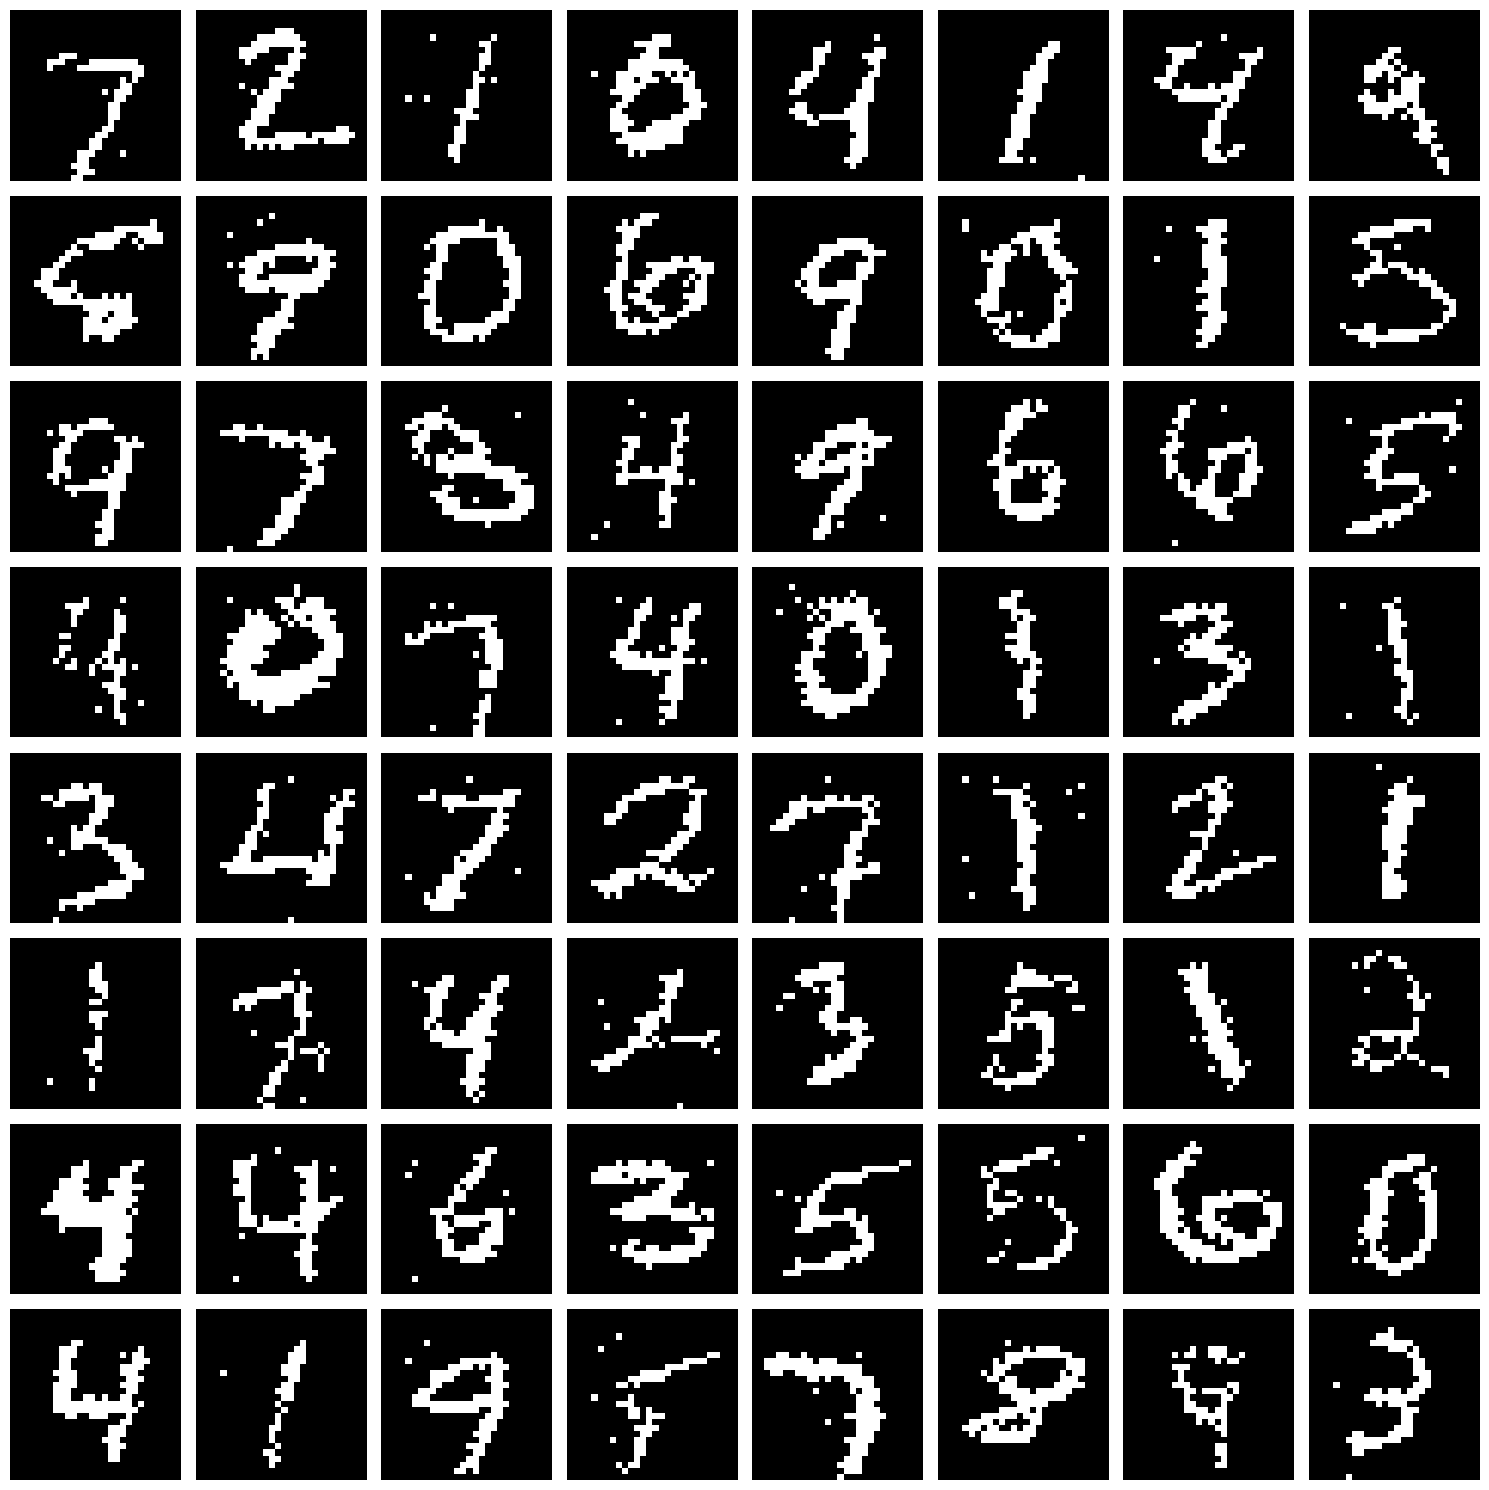

In [8]:
H, W = 28, 28

with torch.no_grad():
  for iter, (images, labels) in enumerate(test_loader):
      images = images.to(device)
      pred = model(images)

      for i in range(H):
          for j in range(W):
              pred[:, :, i, j] = torch.bernoulli(pred[:, :, i, j], out=pred[:, :, i, j])
      break
#torch.bernoulli(input, out=...): 这是伯努利分布（抛硬币分布）采样函数。input 是概率,很有意思的处理

samples = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# f. Evaluation (Generation)

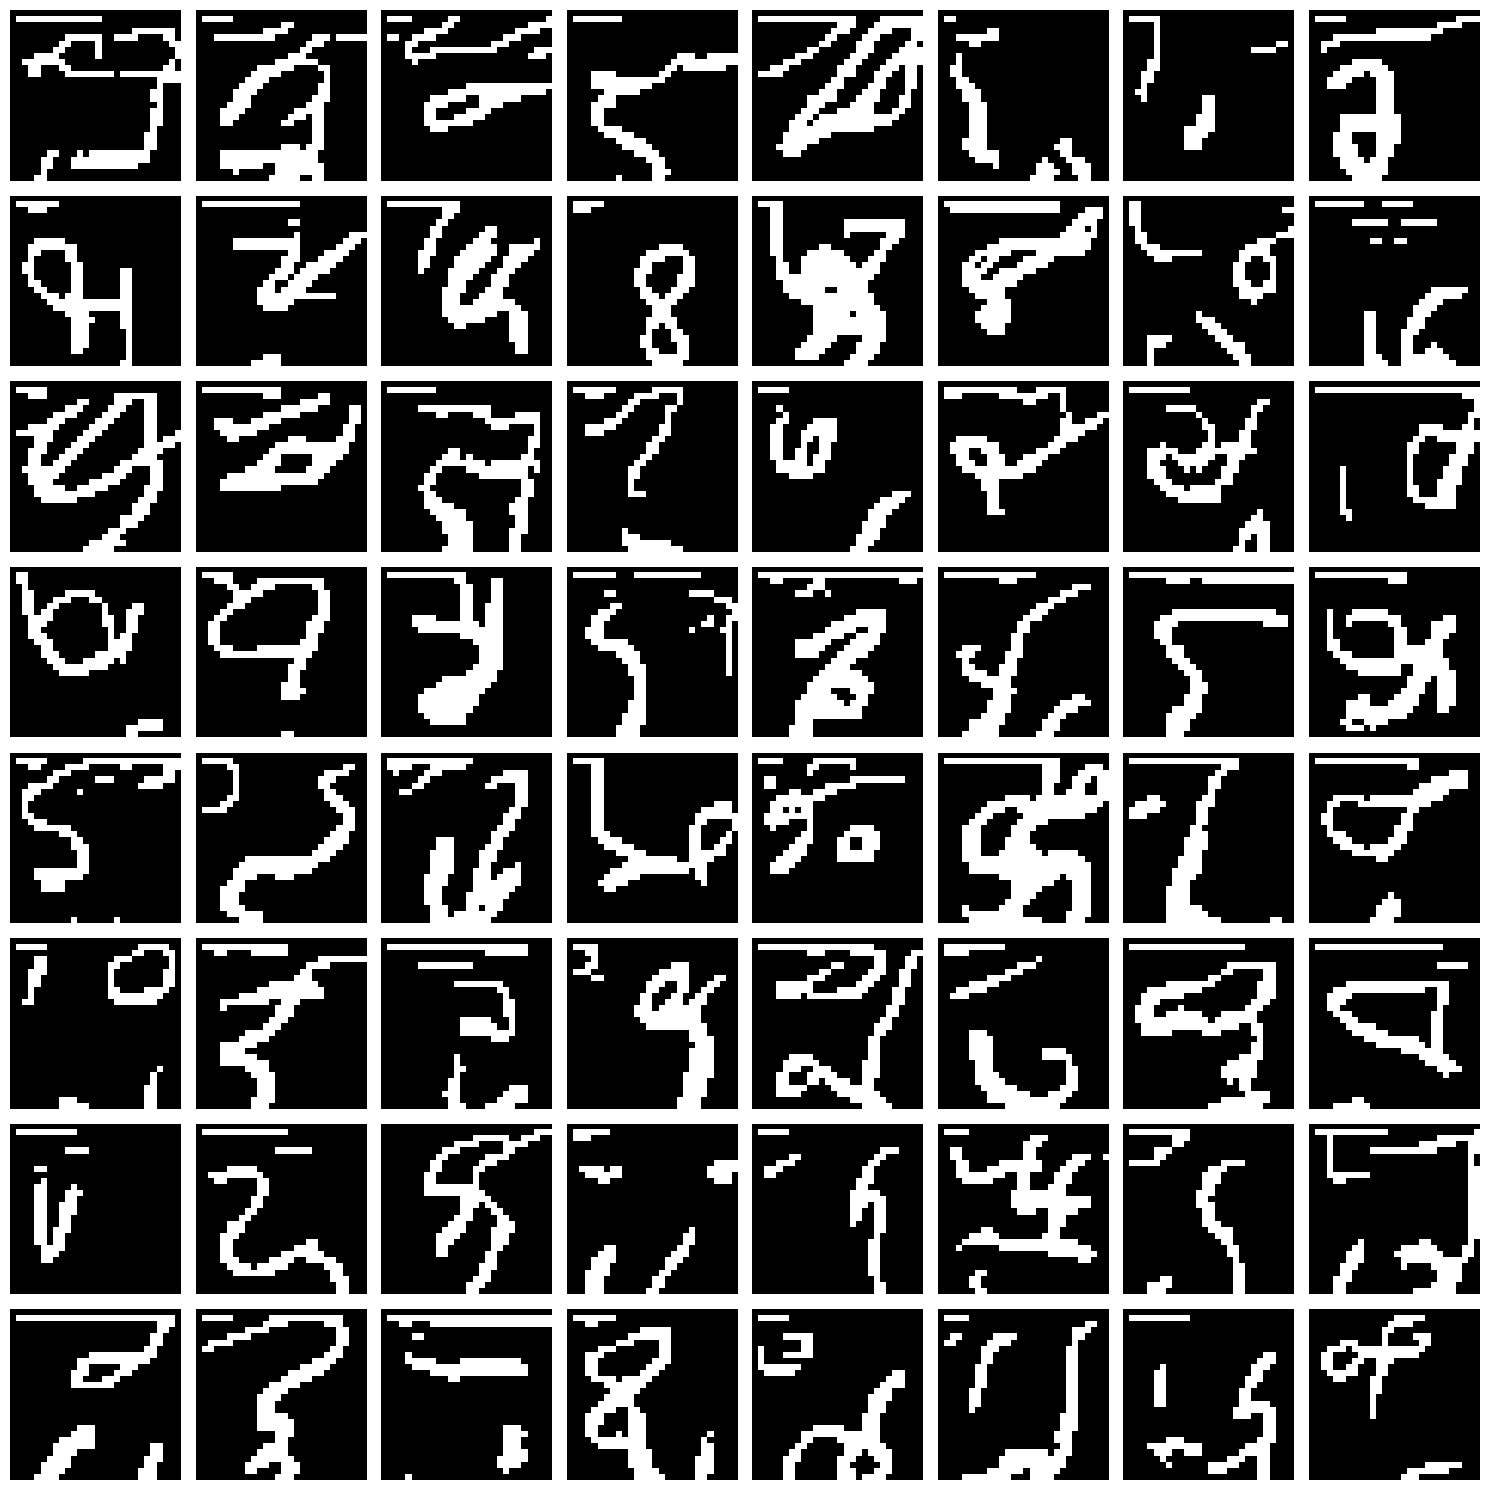

In [9]:
samples = torch.zeros(size=(64, 1, H, W)).to(device)
with torch.no_grad():
    for i in range(H):
        for j in range(W):
            if j > 0 and i > 0:
                out = model(samples)
                samples[:, :, i, j] = torch.bernoulli(out[:, :, i, j], out=samples[:, :, i, j])

samples = samples.cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# **2. Conditional PixelCNN**


# a. Training Function

In [10]:
def train_cond(dataloader, model, optimizer, epochs, n_classes):
    losses = []

    for epoch in tqdm(range(epochs), desc='Epochs'):
        running_loss = 0.0
        batch_progress = tqdm(dataloader, desc='Batches', leave=False)

        for iter, (images, labels) in enumerate(batch_progress):
            images = images.to(device)
            labels = labels.to(device)
            tgt = images.clone()
            labels = F.one_hot(labels, num_classes=n_classes).float()
            pred = model(images, labels)
            loss = bce(pred, tgt)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            avg_loss = running_loss * batch_size / len(train_dataset)
            losses.append(loss.item())

        tqdm.write(f'----\nEpoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}\n')

    return losses

# b. Conditional Masked Convolution

In [ ]:
class ConditionalMaskedConv2d(MaskedConv2d):
    ##################
    ### Problem 3(b): Implement ConditionalMaskedConv2d
    def __init__(self, mask_type, in_channels, out_channels, kernel_size, num_classes, padding=0):
        # 初始化父类(MaskedConv2d)
        super().__init__(mask_type, in_channels=in_channels, out_channels=out_channels, 
                         kernel_size=kernel_size, padding=padding)
        # 增加一个全连接层，将类别条件向量投射到输出通道的维度上
        self.cond_proj = nn.Linear(num_classes, out_channels)

    def forward(self, x, class_condition):
        # 1. 正常的 Masked Conv 算出图像部分的特征: shape [batch, out_channels, H, W]
        out = super().forward(x)
        
        # 2. 将 one-hot label 投射成特征条件
        # class_condition 形状为: [batch, num_classes]
        # cond_proj(class_condition) 变为了: [batch, out_channels]
        cond = self.cond_proj(class_condition)
        
        # 3. 将其转换形状以便能够和 out 直接相加 (Broadcast)unsqueeze(dim) 的作用：在张量的指定维度（dim）上，强行插入一个大小为 1 的新维度。
        # 变为了: [batch, out_channels, 1, 1],z
        cond = cond.unsqueeze(-1).unsqueeze(-1)
        
        # 4. 把条件融入输出中
        return out + cond
    ##################

# c. Model

In [12]:
class ConditionalPixelCNN(nn.Module):
    ##################
    ### Problem 3(b): Implement ConditionalPixelCNN
    def __init__(self, num_classes):
        super().__init__()
        # 与之前的 PixelCNN 框架一致，但是每一层都换成了 ConditionalMaskedConv2d
        # 第一层同样必须是 Type A 掩码，其余为 Type B 掩码
        
        self.conv1 = ConditionalMaskedConv2d('A', in_channels=1, out_channels=64, kernel_size=7, num_classes=num_classes, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.conv2 = ConditionalMaskedConv2d('B', in_channels=64, out_channels=64, kernel_size=3, num_classes=num_classes, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = ConditionalMaskedConv2d('B', in_channels=64, out_channels=64, kernel_size=3, num_classes=num_classes, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.conv4 = ConditionalMaskedConv2d('B', in_channels=64, out_channels=64, kernel_size=3, num_classes=num_classes, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        self.conv5 = ConditionalMaskedConv2d('B', in_channels=64, out_channels=64, kernel_size=3, num_classes=num_classes, padding=1)
        self.bn5 = nn.BatchNorm2d(64)
        
        # 最后一层输出 1 通道（黑白），不需要加入条件
        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x, class_condition):
        # 每次卷积都同时传入图像输入 x 和控制标签 class_condition
        x = F.relu(self.bn1(self.conv1(x, class_condition)))
        x = F.relu(self.bn2(self.conv2(x, class_condition)))
        x = F.relu(self.bn3(self.conv3(x, class_condition)))
        x = F.relu(self.bn4(self.conv4(x, class_condition)))
        x = F.relu(self.bn5(self.conv5(x, class_condition)))
        
        # 使用 sigmoid 将输出投射为概率概率 0~1 的表示
        return torch.sigmoid(self.out_conv(x))
    ##################

# d. Training

In [14]:
##################
epochs = 100
### Problem 3(c): Training
n_classes = 10
model = ConditionalPixelCNN(n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

log = train_cond(train_loader, model, optimizer, epochs, n_classes)
##################


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [1/100], Average Loss: 0.1258



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [2/100], Average Loss: 0.0862



...

----
Epoch [98/100], Average Loss: 0.0770



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [99/100], Average Loss: 0.0770



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [100/100], Average Loss: 0.0770



# e. Evaluation (Reconstruction)

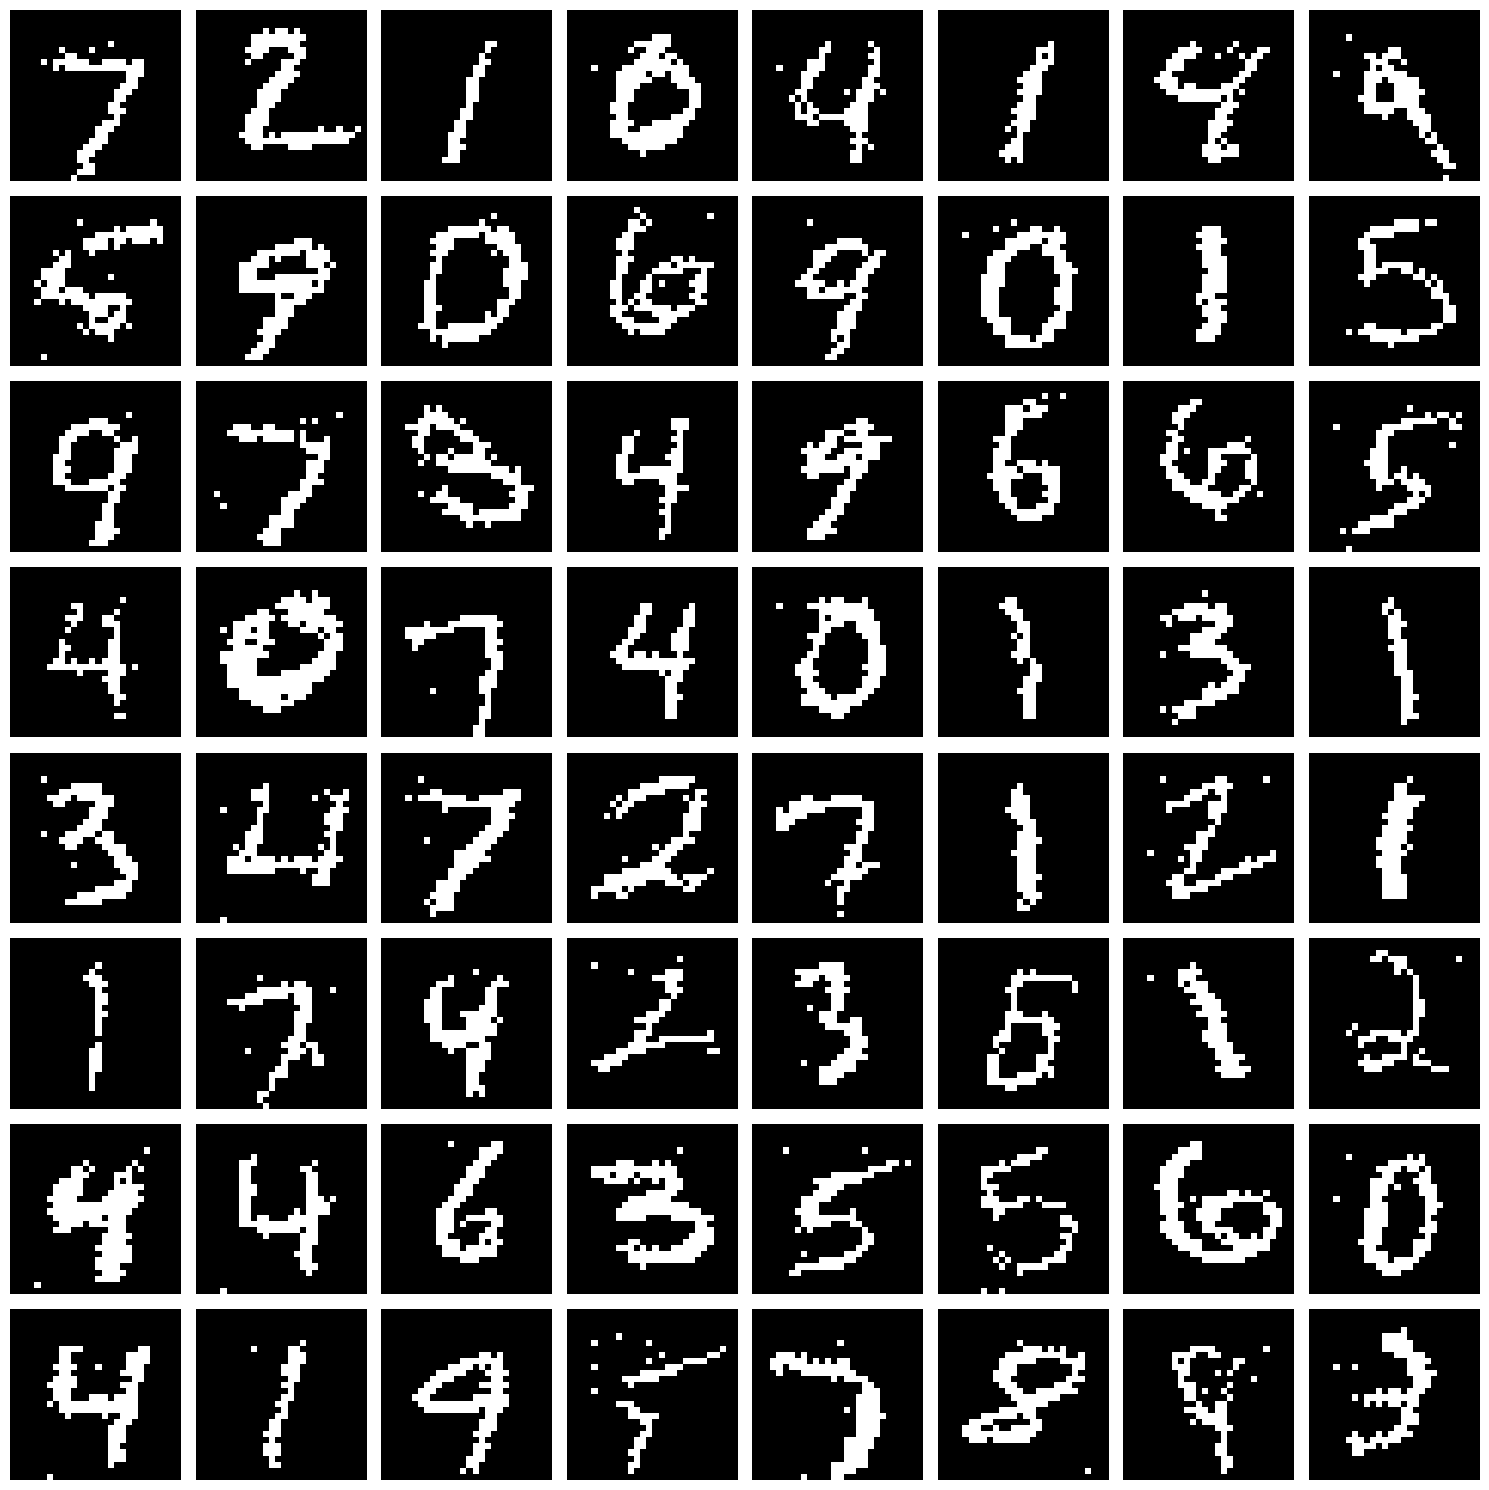

In [15]:
H, W = 28, 28

with torch.no_grad():
  for iter, (images, labels) in enumerate(test_loader):
      images = images.to(device)
      labels = labels.to(device)
      labels = F.one_hot(labels, num_classes=n_classes).float()
      pred = model(images, labels)

      for i in range(H):
          for j in range(W):
              pred[:, :, i, j] = torch.bernoulli(pred[:, :, i, j], out=pred[:, :, i, j])
      break

samples = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# f. Evaluation (Generation)

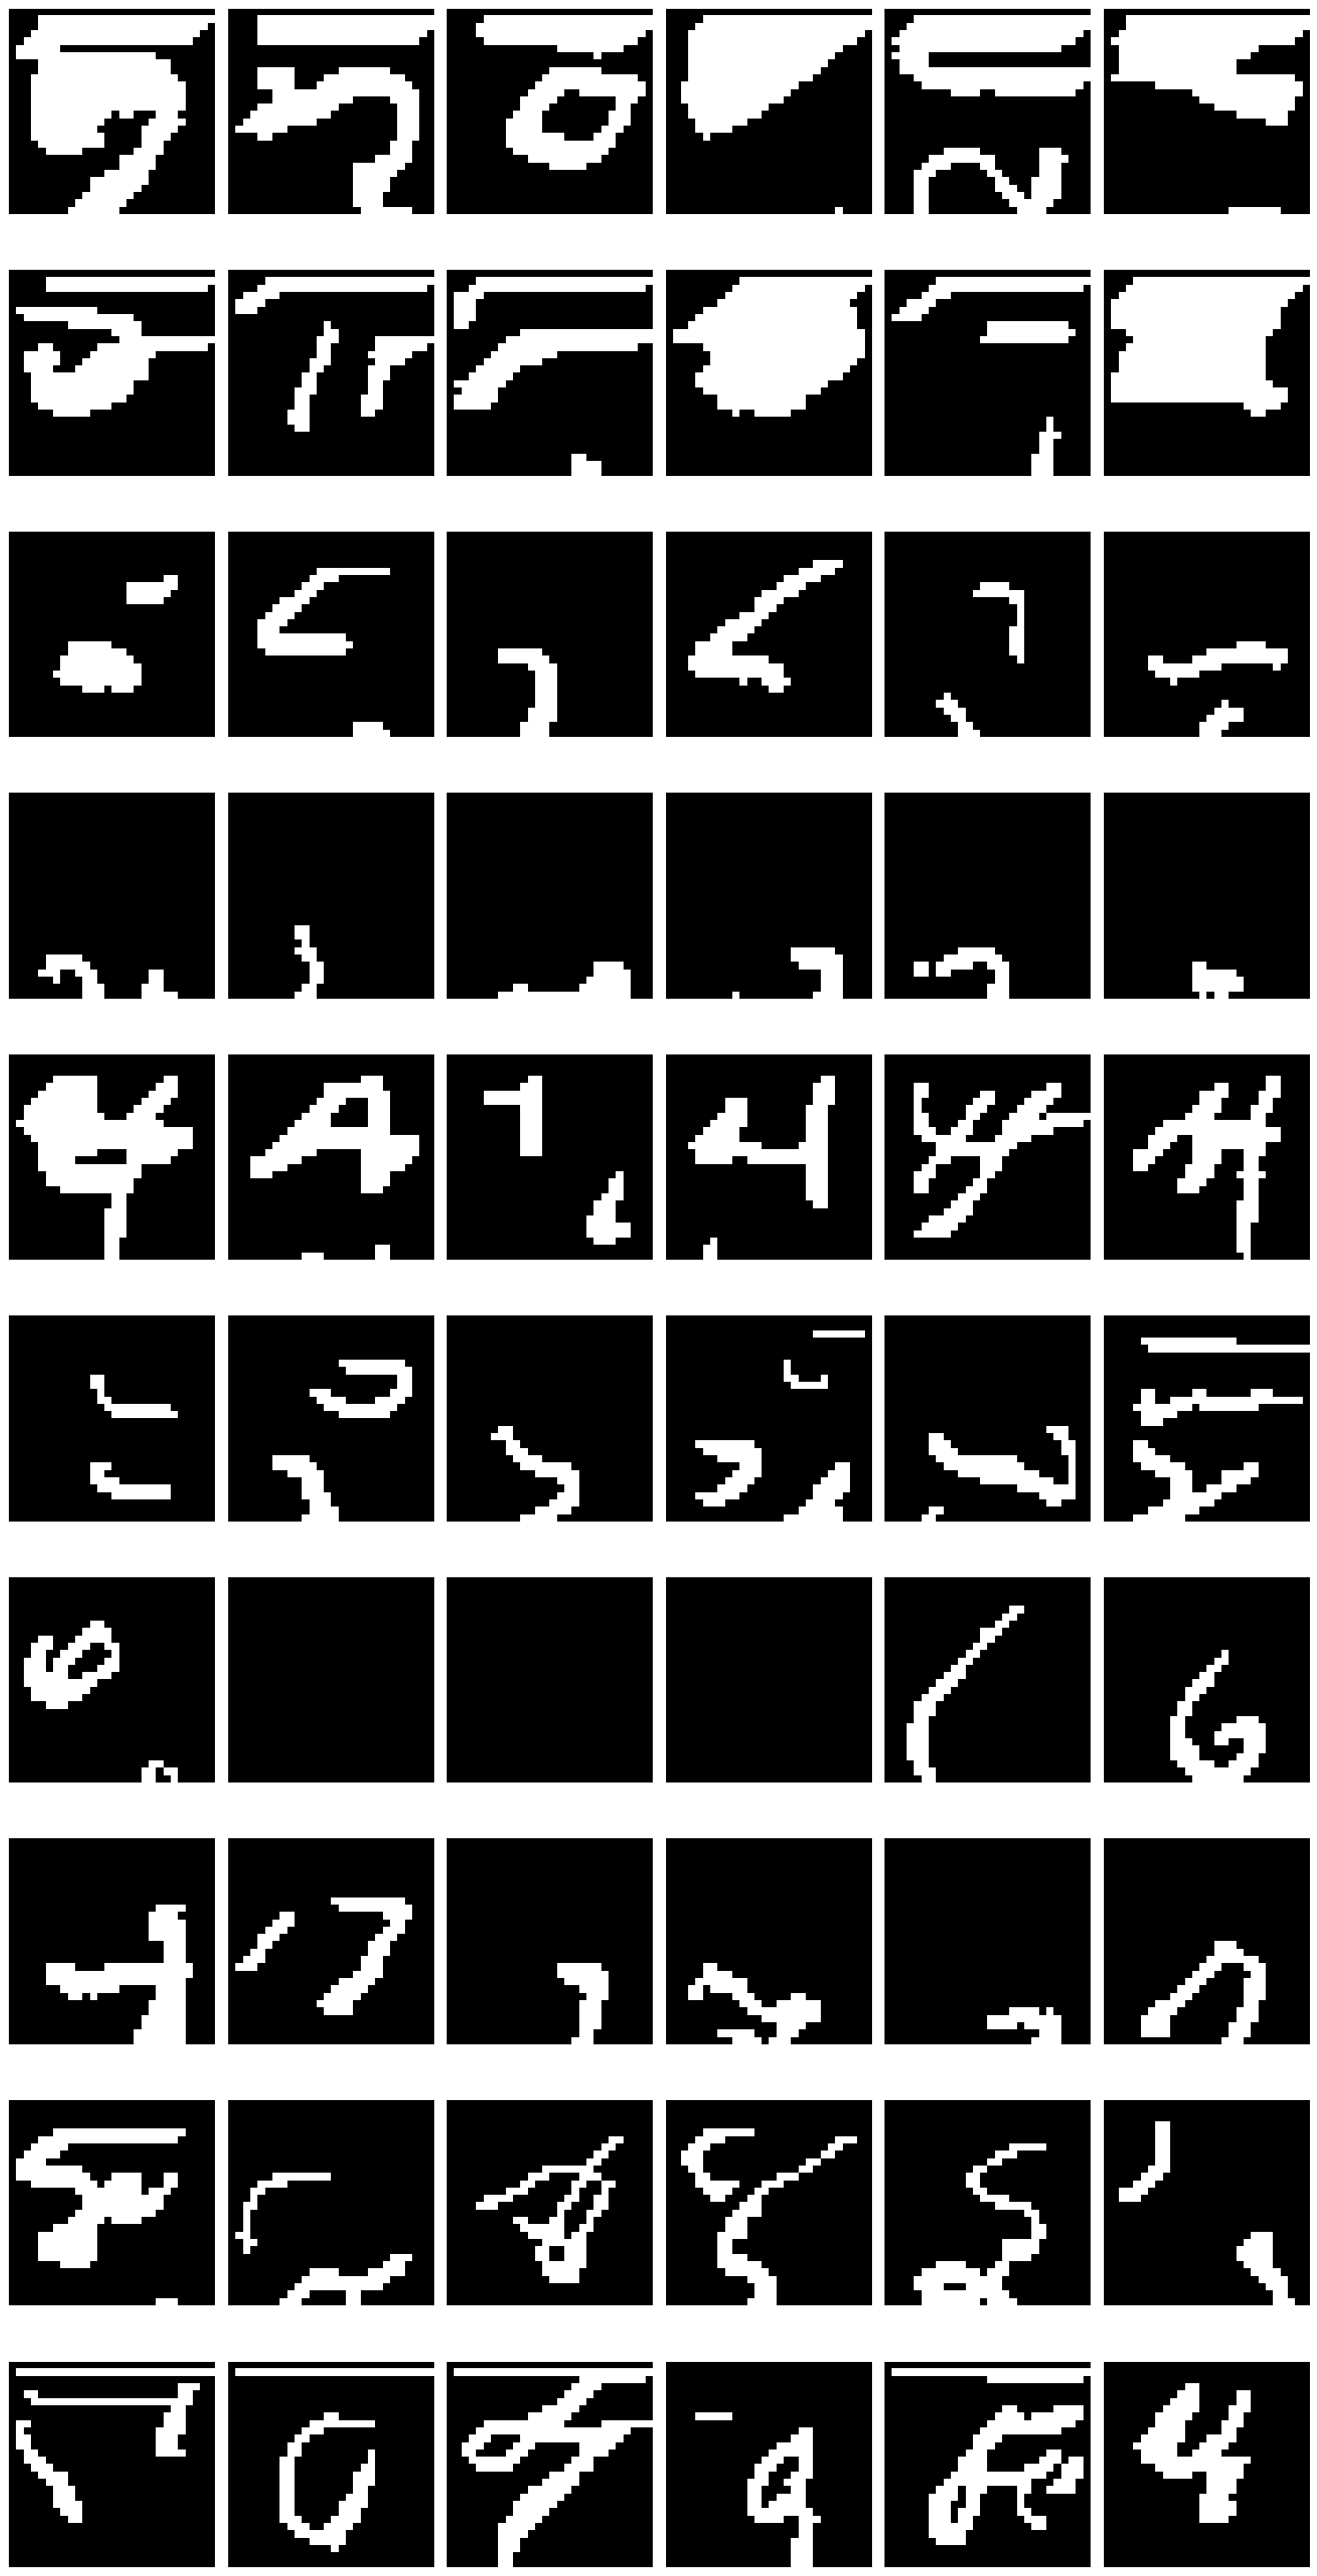

In [16]:
samples = torch.zeros(size=(60, 1, H, W)).to(device)
sample_classes = np.sort(np.array([np.arange(n_classes)] * 6).flatten())
sample_classes = F.one_hot(torch.tensor(sample_classes), num_classes=n_classes).to(device).float()

with torch.no_grad():
    for i in range(H):
        for j in range(W):
            if j > 0 and i > 0:
                out = model(samples, sample_classes)
                samples[:, :, i, j] = torch.bernoulli(out[:, :, i, j], out=samples[:, :, i, j])

samples = samples.cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(10, 6, figsize=(15, 30))

for i in range(60):
    sample = samples[i]
    row, col = divmod(i, 6)
    axes[row, col].imshow(sample, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [13]:
from pypdf import PdfReader
reader = PdfReader('pset2.pdf')
text = ""
for page in reader.pages:
    text += page.extract_text() + "\n"

with open('pset2_text.txt', 'w', encoding='utf-8') as f:
    f.write(text)
print("PDF text extracted successfully!")

PDF text extracted successfully!
